In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from tqdm import tqdm

In [2]:
def generate_anchors_positions(positions_segments, attach):
    positions_anchors = np.zeros((len(attach), 3))

    for idx, a in enumerate(attach):
        positions_anchors[idx] = np.random.normal(positions_segments[a], np.sqrt(Re**2/(3*(N-1)*beta)))
        
        # print(idx, a, positions_segments[a])
    return positions_anchors

def bonded_energy(positions_segments):
    u = 0
    for segment in range(1, len(positions_segments)):
        u += np.linalg.norm(positions_segments[segment] - positions_segments[segment-1])**2

    # u *= 3*(N-1)/(2*Re**2)
    return u

def slipSpring_energy(positions_segments, positions_anchors, anchor):
    w = 0
    
    for idx, a in enumerate(anchor):
        if a == -1:
            continue
        else:
            w += np.linalg.norm(positions_segments[idx] - positions_anchors[a])**2
        # print(a, positions_segments[idx], positions_anchors[a])
    # w *= 3*(N-1)/(2*Re**2)
    return w

def hamiltonian(positions_segments, positions_anchors, anchor):
    h = bonded_energy(positions_segments) + beta*slipSpring_energy(positions_segments, positions_anchors, anchor)
    h *= 3*(N-1)/(2*Re**2)
    return h

def mc_segments(positions_segments, positions_anchors, H_current):
    for _ in range(N):
        segment = np.random.randint(0, N) # segment chosen at random
        
        old_pos = positions_segments[segment].copy()
        
        positions_segments[segment] += np.random.uniform(-a, a, 3)
        H_proposal = hamiltonian(positions_segments, positions_anchors, anchor)
        H_delta = H_proposal - H_current

        if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB*T)):
            H_current = H_proposal
        else:
            positions_segments[segment] = old_pos

    return positions_segments, positions_anchors, H_current

def mc_sliplinks(positions_segments, positions_anchors, anchor, attach, H_current):
    for _ in range(Z):
        j = np.random.randint(0, Z) # slip-link chosen at random
        
        current_attachment = attach[j].copy() # choosing the random attachment point
        proposal_attachment = current_attachment + np.random.choice([-1, 1])

        # Check if the proposal is withing bounds
        if proposal_attachment == -1 or proposal_attachment == N:
            if j%2 == 0:
                j_partner = j+1
            else:
                j_partner = j-1

            # if not, then
            # remove the slip-link duo
            for sliplink in [j, j_partner]:
                segment = attach[sliplink]

                if segment != -1:
                    attach[sliplink] = -1
                    anchor[segment] = -1
            

            # tube renewal
            available_ends = [i for i in [0, N-1] if anchor[i] == -1]
            free_chain_end = np.random.choice(available_ends)
            positions_anchors[j] = np.random.normal(positions_segments[free_chain_end], np.sqrt(Re**2/(3*(N-1)*beta)))
            attach[j] = free_chain_end
            anchor[free_chain_end] = j

            # constraint release
            free_beads = np.where(anchor==-1)[0]
            partner_bead = np.random.choice(free_beads)
            positions_anchors[j_partner] = np.random.normal(positions_segments[partner_bead], np.sqrt(Re**2/(3*(N-1)*beta)))
            attach[j_partner] = partner_bead
            anchor[partner_bead] = j_partner

            continue

        anchor_trial = anchor.copy()
        attach_trial = attach.copy()
        
        anchor_trial[current_attachment] = -1
        anchor_trial[proposal_attachment] = j
        attach_trial[j] = proposal_attachment

        H_proposal = hamiltonian(positions_segments, positions_anchors, anchor_trial)
        H_delta = H_proposal - H_current

        if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB*T)):
            H_current = H_proposal
            anchor = anchor_trial
            attach = attach_trial
            # anchor[current_attachment] = -1 # remove attachment at the chosen sliplink idx
            # anchor[proposal_attachment] = j # add attachment at the proposed sliplink idx
            # attach[j] = proposal_attachment

        else:
            pass
            # anchor[current_attachment] = j
            # anchor[proposal_attachment] = -1
            # attach[j] = current_attachment
    return positions_segments, positions_anchors, anchor, attach, H_current

In [3]:
def plotter(positions_segments, anchor, positions_anchors, step):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Chain backbone
    ax.plot(positions_segments[:, 0], positions_segments[:, 1], positions_segments[:, 2], "-", color="k", alpha=0.5)

    # Beads
    for segment in range(len(positions_segments)):
        if anchor[segment] == -1:
            ax.scatter(*positions_segments[segment], color="k", facecolors="none", alpha=0.8)
        else:
            ax.scatter(*positions_segments[segment], color="k", alpha=0.8)

    # Chain ends
    ax.scatter(*positions_segments[0], color="b", marker="s", s=60, facecolors="none", label="bead N=1")
    ax.scatter(*positions_segments[-1], color="g", marker="s", s=60, facecolors="none", label=f"bead N={len(positions_segments)}")

    # Anchor connections
    for idx, a in enumerate(anchor):
        if a != -1:
            ax.plot(
                [positions_anchors[a, 0], positions_segments[idx, 0]],
                [positions_anchors[a, 1], positions_segments[idx, 1]],
                [positions_anchors[a, 2], positions_segments[idx, 2]],
                color='red', linestyle='-', linewidth=1, alpha=0.4
            )
            ax.scatter(
                *positions_anchors[a],
                color='red', marker="s", alpha=0.4, s=10
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right")
    ax.grid(False)

    ax.set_title(f"step {step}")
    fig.tight_layout()

    output_filepath = f"data/imgs/mcmc/evolution/"
    output_filename = f"step_{step}.png"
    
    if not os.path.exists(output_filepath):
        os.makedirs(output_filepath)
    file = os.path.join(output_filepath, output_filename)
    
    plt.savefig(file, dpi=300)
    plt.close()

In [4]:
# System Parameters
kB = 1
T = 1


N = 16 # Number of segments
# Z = 0 # Number of slip links
Z = N//4 # Number of slip links

Re = 1 # Polymer end-to-end distance
beta = 0.5 # Anchor-segment stiffness (?)

dims = 3 # Space dimensions


a = 2*Re/np.sqrt(N-1) # bead "exploratory" linear dimension -> any proposal confined within such a cube

N_steps = 10000 # MC steps

In [5]:
# Initialize the system

# Initialize polymer
positions_segments = np.zeros((N, dims))

# whereby, assumed that the first segment is initialized at (0, 0, 0)
for segment in range(1, N):
    # print(segment)
    positions_segments[segment] = positions_segments[segment-1] + np.random.normal(0, 1, dims)

# Beads with slip-springs
# Get the index of the beads with the slip spring
attach = np.random.choice(N, Z, replace=False)

# "idx-ordered" list of slip springs (similar to a hash table)
anchor = -1*np.ones(N, dtype=np.int64)
for idx, link in enumerate(attach):
    anchor[link] = idx

positions_anchors = generate_anchors_positions(positions_segments, attach)

# Visualize initial config.
plotter(positions_segments, anchor, positions_anchors, step=0)

print(bonded_energy(positions_segments), slipSpring_energy(positions_segments, positions_anchors, anchor))
print(hamiltonian(positions_segments, positions_anchors, anchor))

38.66000569806494 0.8300337730934408
879.1880081537624


In [6]:
# sequential: exhaust segment moves first and then exhause slip-links moves
R = []
E = []
for step in tqdm(range(N_steps)):
    # if step%100 == 0:
    #     plotter(positions_segments, anchor, positions_anchors, step)
    
    H_current = hamiltonian(positions_segments, positions_anchors, anchor)
    
    # MC on segment
    positions_segments, positions_anchors, H_current = mc_segments(positions_segments, positions_anchors, H_current)

    # MC on slip-links
    positions_segments, positions_anchors, anchor, attach, H_current = mc_sliplinks(positions_segments, positions_anchors, anchor, attach, H_current)

    # print(attach)

    #     print(current_attachment, proposal_attachment)
    # print(f"step {step}")
    R.append(np.linalg.norm(positions_segments[-1]-positions_segments[0]))
    E.append(hamiltonian(positions_segments, positions_anchors, anchor))

100%|███████████████████████████████████| 10000/10000 [00:08<00:00, 1209.65it/s]


In [7]:
print(bonded_energy(positions_segments), slipSpring_energy(positions_segments, positions_anchors, anchor))
print(hamiltonian(positions_segments, positions_anchors, anchor))


0.9834606095705398 0.4190071183608548
26.841693796896767


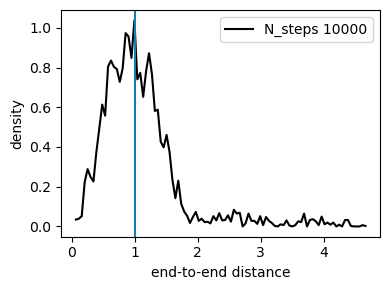

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))

counts, bins = np.histogram(R, bins=100, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
ax.plot(bin_centers, counts, color="k", label=f"N_steps {N_steps}")
ax.legend(loc = "upper right")
ax.set_xlabel("end-to-end distance")
ax.set_ylabel("density")
ax.axvline(Re)
fig.tight_layout()

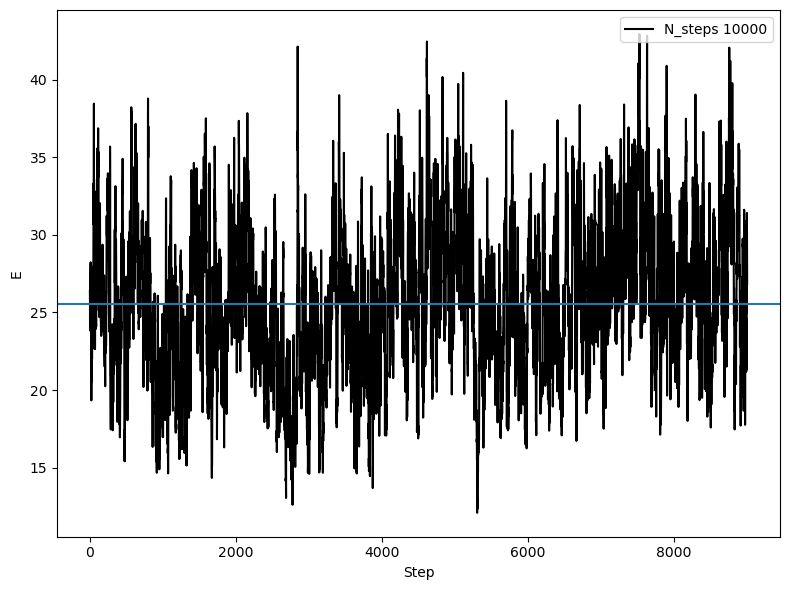

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(E[1000:], color="k", label=f"N_steps {N_steps}")
ax.axhline(np.mean(E[1000:]))
ax.legend(loc = "upper right")
ax.set_xlabel("Step")
ax.set_ylabel("E")
fig.tight_layout()